# 06 — Compare multiple runs

Place several `exp_id`s in the list below to compare them side-by-side
(e.g. PPO vs heuristic baselines, different seeds, ablations).

In [1]:
import sys, pathlib
# Make ``utils.py`` importable whether the notebook is opened from
# project root or from analysis/.
_here = pathlib.Path.cwd()
for cand in (_here, _here / "analysis", _here.parent):
    if (cand / "utils.py").exists():
        sys.path.insert(0, str(cand))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    list_runs, latest_run, load_run, load_runs,
    group_columns, group_columns_by_prefix, strip_prefix, rolling_mean,
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

In [2]:
# Edit this list — defaults to "the 3 most recently modified runs".
runs_df = list_runs()
EXP_IDS = runs_df[runs_df["has_episodes"]].head(3)["exp_id"].tolist()
print("Comparing:", EXP_IDS)
data = load_runs(EXP_IDS, with_steps=False)

Comparing: ['nb_least_busy', 'nb_random']


## Return curves overlaid

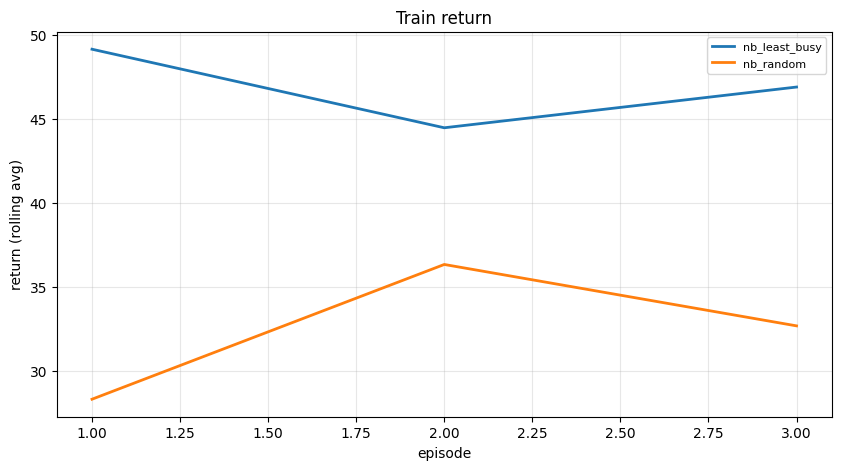

In [3]:
fig, ax = plt.subplots()
for exp_id, (ep, _, _) in data.items():
    train = ep[ep["phase"] == "train"]
    if train.empty: continue
    smooth = rolling_mean(train["return"], window=max(3, len(train)//30 or 1))
    ax.plot(train["episode"], smooth, label=exp_id, lw=2)
ax.set(xlabel="episode", ylabel="return (rolling avg)", title="Train return")
ax.legend(fontsize=8)
plt.show()

## Final-return distribution per run

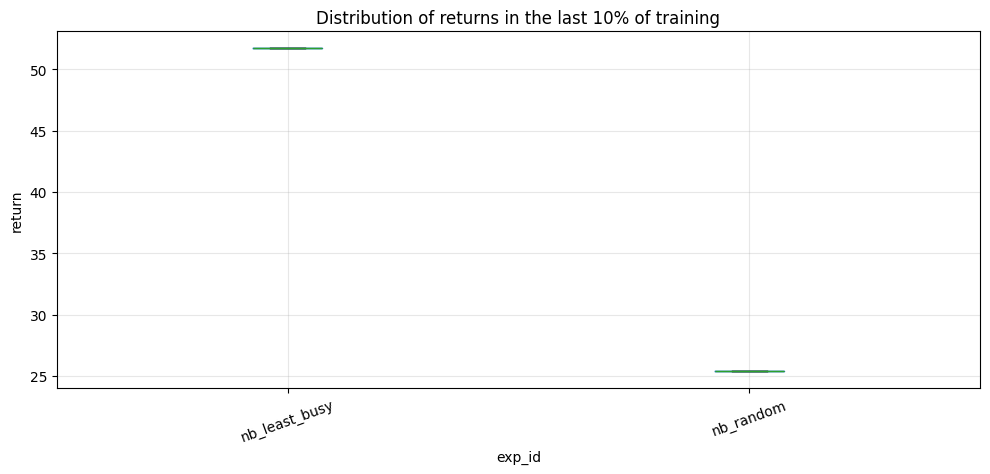

In [4]:
rows = []
for exp_id, (ep, _, _) in data.items():
    train = ep[ep["phase"] == "train"]
    tail_n = min(20, max(1, len(train) // 10))
    last = train["return"].tail(tail_n)
    for v in last:
        rows.append({"exp_id": exp_id, "return": v})
final_df = pd.DataFrame(rows)

if not final_df.empty:
    fig, ax = plt.subplots()
    final_df.boxplot(column="return", by="exp_id", ax=ax, rot=20)
    ax.set_title("Distribution of returns in the last 10% of training")
    plt.suptitle("")
    ax.set_ylabel("return")
    plt.tight_layout(); plt.show()

## Headline-metric comparison table

In [5]:
rows = []
for exp_id, (ep, _, cfg) in data.items():
    train = ep[ep["phase"] == "train"]
    tail = train.tail(max(1, len(train) // 10))
    rows.append({
        "exp_id": exp_id,
        "agent": cfg.get("agent", {}).get("agent_type"),
        "seed": cfg.get("experiment", {}).get("seed"),
        "n_train_episodes": int(len(train)),
        "mean_return_tail": float(tail["return"].mean()) if not tail.empty else float("nan"),
        "best_return": float(train["return"].max()) if not train.empty else float("nan"),
        "total_wall_clock_s": float(train["wall_clock_seconds"].sum()) if "wall_clock_seconds" in train.columns else float("nan"),
    })
pd.DataFrame(rows).set_index("exp_id").round(3)

,agent,seed,n_train_episodes,mean_return_tail,best_return,total_wall_clock_s
exp_id,,,,,,
nb_least_busy,least_busy,0,3,51.763,51.763,0.192
nb_random,random,0,3,25.366,44.367,0.229
